# Bag of Words & Logistic Regression Classifier Baseline

In [31]:
import csv
import random

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, classification_report

In [32]:
languages = ['af', 'de', 'en', 'es', 'fr', 'id', 'it', 'nl', 'pt', 'sv', 'tl', 'tr']

In [33]:
# Load the train, test, validation data
train_dataset = []
test_dataset = []
validation_dataset = []

train_path = f"dataset/train.csv"
with open(train_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        train_dataset.append(row)

    random.shuffle(train_dataset)
    train_dataset = [{'id': item['id'], 'text': item['text'], 'lang': item['lang']} for item in train_dataset]
    
test_path = f"dataset/test.csv"
with open(test_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        test_dataset.append(row)

    random.shuffle(test_dataset)
    test_dataset = [{'id': item['id'], 'text': item['text']} for item in test_dataset]

validation_path = f"dataset/validation.csv"
with open(validation_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        validation_dataset.append(row)

    random.shuffle(validation_dataset)
    validation_dataset = [{'id': item['id'], 'text': item['text'], 'lang': item['lang']} for item in validation_dataset]

## Visualizing the data

In [34]:
# Visualize the training dataset
print("Sample training data:")
train_df = pd.DataFrame(train_dataset)
train_df.head(10)

Sample training data:


,id,text,lang
0,34990,create an email to my brother asking him what ...,en
1,33177,i play ang audiobook na swan sa una,tl
2,12827,ich mag alt rock musik,de
3,58081,está solarengo lá fora,pt
4,47667,olly was läuft im lumen kino,de
5,48456,éclaire la lumière de ma chambre,fr
6,10607,einen status mit den letzten notizen von meine...,de
7,15944,zeig mir die nachrichten von c. n. n.,de
8,3716,sende einen tweet an h und m dass ich nicht gu...,de
9,6750,informations sur rowan atkinson,fr


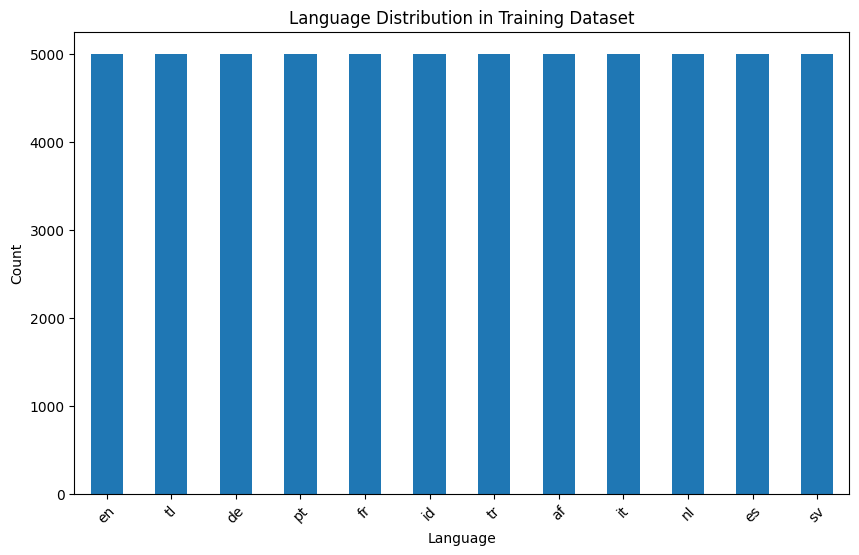

In [35]:
plt.figure(figsize=(10, 6))
train_df['lang'].value_counts().plot(kind='bar')
plt.title('Language Distribution in Training Dataset')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [36]:
# Visualize the test dataset
print("Sample test data:")
test_df = pd.DataFrame(test_dataset)
test_df.head(10)

Sample test data:


,id,text
0,15558,güneş ne ​​kadar uzaklıkta
1,29093,ecco la verità sulle calorie delle gallette di...
2,28759,per favore aggiungi questa email ai miei contatti
3,24381,saya butuh resep untuk sayur lodeh
4,24012,vertel me over economie en b. b. p. over india...
5,29739,what's my schedule today
6,25126,send a reply if it is very important
7,26530,gaano kalamig ngayon
8,19195,ipakita mga podcast
9,24128,pode enviar um email para


In [37]:
# Visualize the validation dataset
print("Sample validation data:")
validation_df = pd.DataFrame(validation_dataset)
validation_df.head(10)

Sample validation data:


,id,text,lang
0,16879,apakah seharusnya salju minggu ini,id
1,499,gör ett rum mörkare,sv
2,19145,tengo algún recordatorio pendiente,es
3,3713,ändere meiner lichter auf eine zufällige farbe,de
4,23877,spiele den podcast von vorne,de
5,11513,comienza con la limpieza de la casa,es
6,10298,set a weekly appointment reminder,en
7,22629,kablonete hizmetlerinin berbat olduğunu bildir...,tr
8,16680,le monde prendra-t-il fin quand,fr
9,2642,je ne veux plus de cette liste,fr


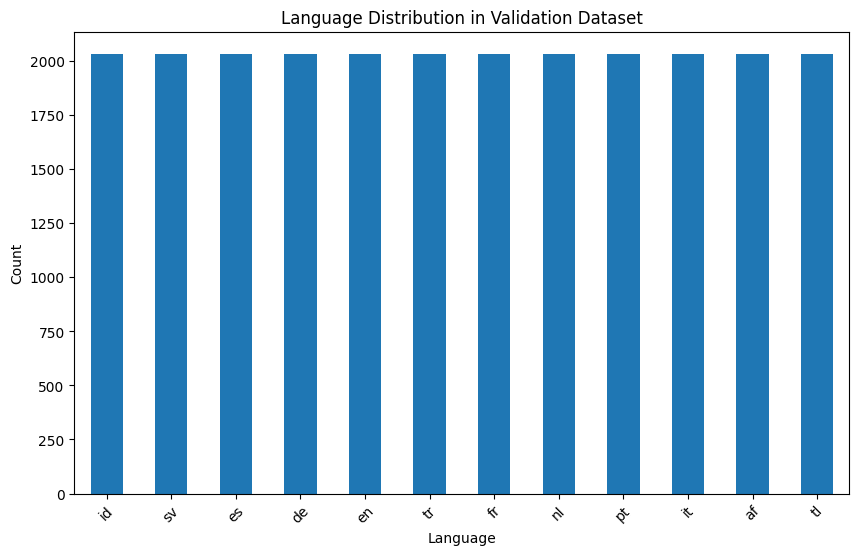

In [38]:
plt.figure(figsize=(10, 6))
validation_df['lang'].value_counts().plot(kind='bar')
plt.title('Language Distribution in Validation Dataset')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## Model Training

In [39]:
# Split the data into features and labels
X_train = [item['text'] for item in train_dataset]
y_train = [item['lang'] for item in train_dataset]

X_test = [item['text'] for item in test_dataset]

X_val = [item['text'] for item in validation_dataset]
y_val = [item['lang'] for item in validation_dataset]

In [40]:
# Baseline prediction: Randomly assign a language label to each test sample
def baseline_predict(test_data):
    predictions = []
    for _ in test_data:
        label = random.choice(languages)
        predictions.append(label)
    return predictions

## Model Evaluation

In [41]:
y_pred = baseline_predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average='macro')

print(f"Accuracy: {accuracy*100:.4f}%")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Accuracy: 8.2923%
F1 Score: 0.0829

Classification Report:
              precision    recall  f1-score   support

          af       0.08      0.08      0.08      2033
          de       0.08      0.08      0.08      2033
          en       0.08      0.08      0.08      2033
          es       0.09      0.09      0.09      2033
          fr       0.08      0.08      0.08      2033
          id       0.08      0.08      0.08      2033
          it       0.09      0.09      0.09      2033
          nl       0.08      0.08      0.08      2033
          pt       0.09      0.09      0.09      2033
          sv       0.07      0.07      0.07      2033
          tl       0.08      0.09      0.08      2033
          tr       0.08      0.08      0.08      2033

    accuracy                           0.08     24396
   macro avg       0.08      0.08      0.08     24396
weighted avg       0.08      0.08      0.08     24396



In [42]:
# Run your prediction on the test set and save the results to a CSV file
y_test_pred = baseline_predict(test_dataset)

output_df = pd.DataFrame({'id': [item['id'] for item in test_dataset], 'lang': y_test_pred})
output_df.to_csv('prediction_results.csv', index=False)